# Fase 8 — Análisis Exploratorio de Datos (EDA) de Golazo

**Objetivo:** entender qué está ocurriendo realmente dentro del canal antes de proponer ninguna solución. Se sigue el guion: limpieza → estadísticas → visualizaciones → patrones → anomalías → relaciones → segmentaciones → conclusiones → problemas detectados → problema elegido → traducción a Ciencia de Datos.

**Requisito previo:** haber ejecutado, desde la raíz del proyecto:
```
python -m src.generador_sintetico
python -m src.cargar_datos
```
para tener la base de datos PostgreSQL `golazo_growup` poblada con las 8 tablas.

## 0. Carga de datos desde la base de datos

In [23]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sqlalchemy import create_engine

from src import db_connection as dbc

# Reutilizamos la MISMA configuración que ya usa db_connection.py
# (DATABASE_URL si existe -p. ej. Neon-, si no las variables sueltas locales)
url = dbc.DATABASE_URL or (
    f"postgresql+psycopg2://{dbc.DB_CONFIG['user']}:{dbc.DB_CONFIG['password']}"
    f"@{dbc.DB_CONFIG['host']}:{dbc.DB_CONFIG['port']}/{dbc.DB_CONFIG['dbname']}"
)
if url.startswith('postgresql://'):
    url = url.replace('postgresql://', 'postgresql+psycopg2://', 1)

engine = create_engine(url)

canal = pd.read_sql('SELECT * FROM canal', engine)
video = pd.read_sql('SELECT * FROM video', engine, parse_dates=['fecha_publicacion'])
video_tag = pd.read_sql('SELECT * FROM video_tag', engine)
evolucion = pd.read_sql('SELECT * FROM evolucion_diaria', engine, parse_dates=['fecha'])
retencion = pd.read_sql('SELECT * FROM retencion_audiencia', engine)
demografia = pd.read_sql('SELECT * FROM demografia', engine)
trafico = pd.read_sql('SELECT * FROM trafico', engine)
ingresos = pd.read_sql('SELECT * FROM ingresos', engine, parse_dates=['fecha'])

print('Filas por tabla:')
for nombre, df in [('canal', canal), ('video', video), ('video_tag', video_tag),
                    ('evolucion_diaria', evolucion), ('retencion_audiencia', retencion),
                    ('demografia', demografia), ('trafico', trafico), ('ingresos', ingresos)]:
    print(f'  {nombre:22s}: {len(df)}')

Filas por tabla:
  canal                 : 1
  video                 : 338
  video_tag             : 1014
  evolucion_diaria      : 30
  retencion_audiencia   : 7098
  demografia            : 12
  trafico               : 7
  ingresos              : 30


## 1. Limpieza de datos

Aunque los datos ya pasaron validaciones al generarlos (Fase 4) y al cargarlos (Fase 7, con `CHECK` en la base de datos), un EDA serio **repite estas comprobaciones siempre**, nunca las da por hechas — puede haber cambiado algo, o pueden aparecer problemas que las restricciones de la base de datos no cubren (p. ej. duplicados lógicos, fechas fuera de rango razonable).

In [24]:
problemas_limpieza = []

# Duplicados
if video['video_id'].duplicated().any():
    problemas_limpieza.append(f"{video['video_id'].duplicated().sum()} video_id duplicados en 'video'")

# Nulos
for nombre, df in [('video', video), ('evolucion_diaria', evolucion), ('ingresos', ingresos)]:
    nulos = df.isna().sum()
    nulos = nulos[nulos > 0]
    if len(nulos):
        problemas_limpieza.append(f"Nulos en '{nombre}': {dict(nulos)}")

# Rangos absurdos
if (video['duracion_segundos'] <= 0).any():
    problemas_limpieza.append('Vídeos con duración <= 0')
if (video['views_totales'] < 0).any():
    problemas_limpieza.append('Vídeos con vistas negativas')
suma_demografia = demografia['viewer_percentage'].sum()
if not (99 <= suma_demografia <= 101):
    problemas_limpieza.append(f'Demografía no suma ~100% (suma real: {suma_demografia:.2f})')

# Fechas fuera de rango razonable (antes de la creación del canal, o en el futuro)
fecha_creacion = pd.to_datetime(canal['fecha_creacion'].iloc[0])
fuera_de_rango = video[video['fecha_publicacion'] < fecha_creacion]
if len(fuera_de_rango):
    problemas_limpieza.append(f'{len(fuera_de_rango)} vídeos publicados antes de la fecha de creación del canal')

if problemas_limpieza:
    print('Problemas de limpieza encontrados:')
    for p in problemas_limpieza:
        print(f'  - {p}')
else:
    print('Sin problemas de limpieza detectados: tipos, duplicados, nulos y rangos correctos.')

Sin problemas de limpieza detectados: tipos, duplicados, nulos y rangos correctos.


## 2. Estadísticas descriptivas

In [25]:
print('--- Vídeos: estadísticas generales ---')
display(video[['duracion_segundos', 'views_totales', 'likes', 'comentarios']].describe().round(1))

print('\n--- Vídeos por categoría ---')
display(video.groupby('categoria').agg(
    n_videos=('video_id', 'count'),
    views_medias=('views_totales', 'mean'),
    likes_medios=('likes', 'mean'),
    duracion_media_seg=('duracion_segundos', 'mean'),
).round(1).sort_values('views_medias', ascending=False))

--- Vídeos: estadísticas generales ---


,duracion_segundos,views_totales,likes,comentarios
count,338.0,338.0,338.0,338.0
mean,772.8,5541.1,207.6,45.0
std,955.7,5457.2,207.4,47.6
min,60.0,80.0,2.0,0.0
25%,184.5,1472.2,48.0,9.0
50%,550.0,3508.0,129.0,27.5
75%,843.5,8584.2,320.2,65.0
max,5284.0,20091.0,819.0,225.0



--- Vídeos por categoría ---


,n_videos,views_medias,likes_medios,duracion_media_seg
categoria,,,,
Curiosidades de fútbol,23,7132.3,268.8,655.5
Seguimiento del club,154,6090.7,226.0,790.5
Fichajes,54,5015.2,193.1,779.5
Opinión post-partido,90,4802.5,181.0,820.8
Afición,17,3989.5,144.7,496.4


In [26]:
print('--- Evolución diaria: estadísticas ---')
evolucion['suscriptores_netos'] = evolucion['subscribers_gained'] - evolucion['subscribers_lost']
display(evolucion[['views', 'estimated_minutes_watched', 'average_view_duration',
                    'subscribers_gained', 'subscribers_lost', 'suscriptores_netos']].describe().round(1))

print('\n--- Ingresos: estadísticas ---')
display(ingresos[['estimated_revenue', 'cpm']].describe().round(2))
rpm_medio = (ingresos['estimated_revenue'].sum() / evolucion['views'].sum()) * 1000
print(f"RPM medio real del periodo (ingreso total / vistas totales * 1000): {rpm_medio:.2f} EUR")

--- Evolución diaria: estadísticas ---


,views,estimated_minutes_watched,average_view_duration,subscribers_gained,subscribers_lost,suscriptores_netos
count,30.0,30.0,30.0,30.0,30.0,30.0
mean,10033.3,48662.0,291.3,30.0,3.8,26.2
std,2867.7,17193.0,69.0,8.5,1.8,7.2
min,6248.0,20967.0,181.9,19.0,1.0,16.0
25%,7658.2,36774.8,235.5,23.0,2.2,20.2
50%,8950.5,48226.0,280.1,27.0,4.0,23.5
75%,12428.0,58340.0,345.6,36.8,4.8,31.8
max,15917.0,89425.0,400.8,48.0,7.0,41.0



--- Ingresos: estadísticas ---


,estimated_revenue,cpm
count,30.00,30.00
mean,6.65,2.21
std,1.90,0.13
min,4.14,1.96
25%,5.08,2.15
50%,5.94,2.21
75%,8.24,2.30
max,10.55,2.40


RPM medio real del periodo (ingreso total / vistas totales * 1000): 0.66 EUR


## 3. Visualizaciones

### 3.1 Evolución diaria: vistas y suscriptores

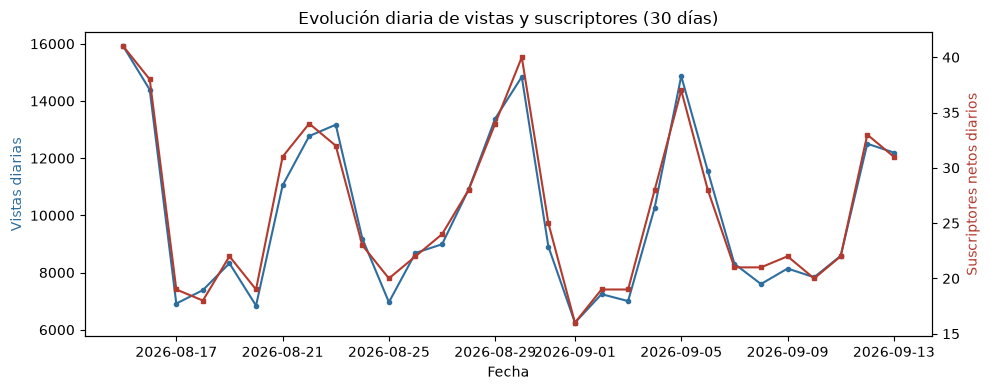

In [27]:
fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.plot(evolucion['fecha'], evolucion['views'], color='#2E6E9E', marker='o', markersize=3, label='Vistas')
ax1.set_ylabel('Vistas diarias', color='#2E6E9E')
ax1.set_xlabel('Fecha')

ax2 = ax1.twinx()
ax2.plot(evolucion['fecha'], evolucion['suscriptores_netos'], color='#B23A2E', marker='s', markersize=3, label='Suscriptores netos')
ax2.set_ylabel('Suscriptores netos diarios', color='#B23A2E')

plt.title('Evolución diaria de vistas y suscriptores (30 días)')
fig.tight_layout()
plt.show()

### 3.2 Rendimiento medio por categoría de contenido

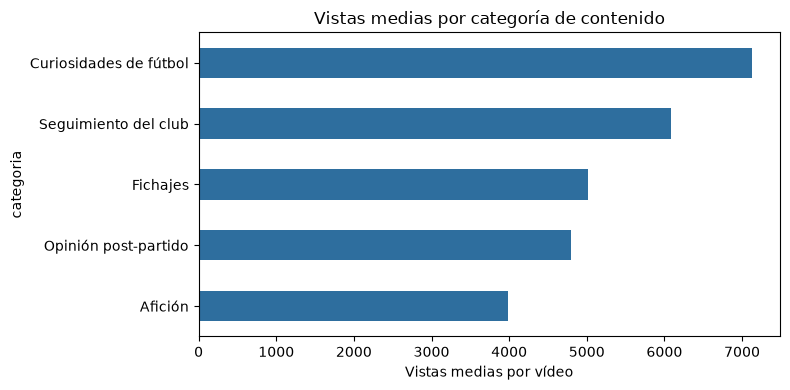

In [28]:
resumen_categoria = video.groupby('categoria')['views_totales'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 4))
resumen_categoria.plot(kind='barh', color='#2E6E9E')
plt.xlabel('Vistas medias por vídeo')
plt.title('Vistas medias por categoría de contenido')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.3 Distribución de la duración de los vídeos

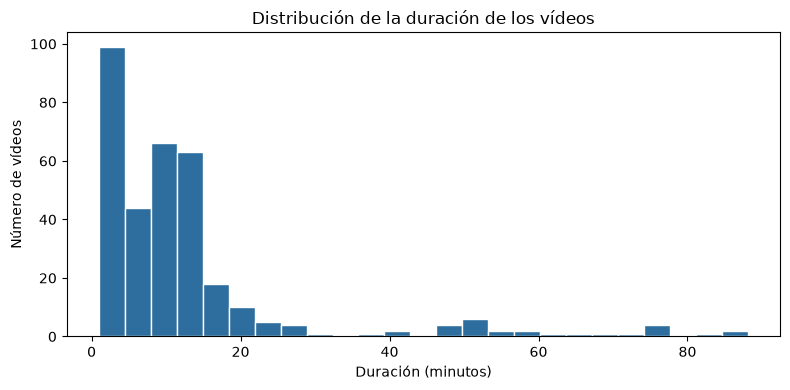

In [29]:
plt.figure(figsize=(8, 4))
plt.hist(video['duracion_segundos'] / 60, bins=25, color='#2E6E9E', edgecolor='white')
plt.xlabel('Duración (minutos)')
plt.ylabel('Número de vídeos')
plt.title('Distribución de la duración de los vídeos')
plt.tight_layout()
plt.show()

### 3.4 Curva de retención media de audiencia

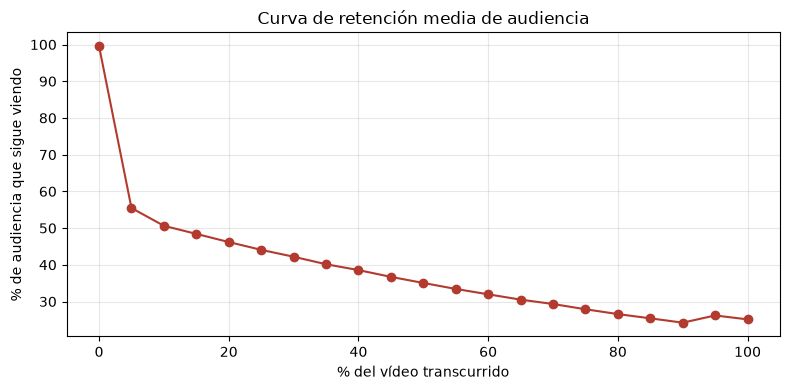

In [30]:
curva_retencion = retencion.groupby('elapsed_video_time_ratio')['audience_watch_ratio'].mean()

plt.figure(figsize=(8, 4))
plt.plot(curva_retencion.index * 100, curva_retencion.values * 100, color='#B23A2E', marker='o')
plt.xlabel('% del vídeo transcurrido')
plt.ylabel('% de audiencia que sigue viendo')
plt.title('Curva de retención media de audiencia')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 3.5 Fuentes de tráfico

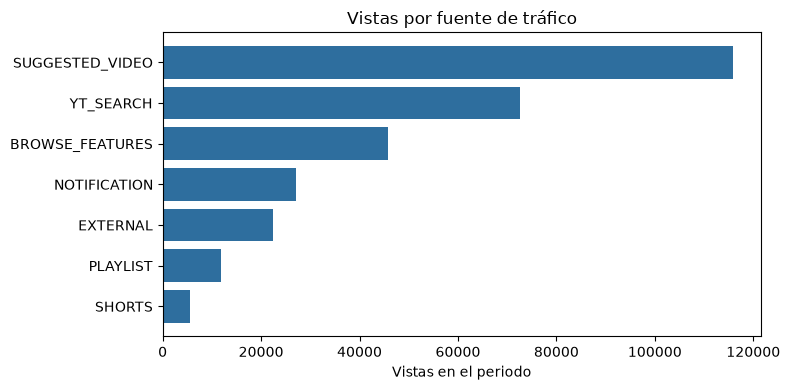

In [31]:
trafico_ordenado = trafico.sort_values('views', ascending=False)

plt.figure(figsize=(8, 4))
plt.barh(trafico_ordenado['traffic_source_type'], trafico_ordenado['views'], color='#2E6E9E')
plt.xlabel('Vistas en el periodo')
plt.title('Vistas por fuente de tráfico')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### 3.6 Demografía de la audiencia

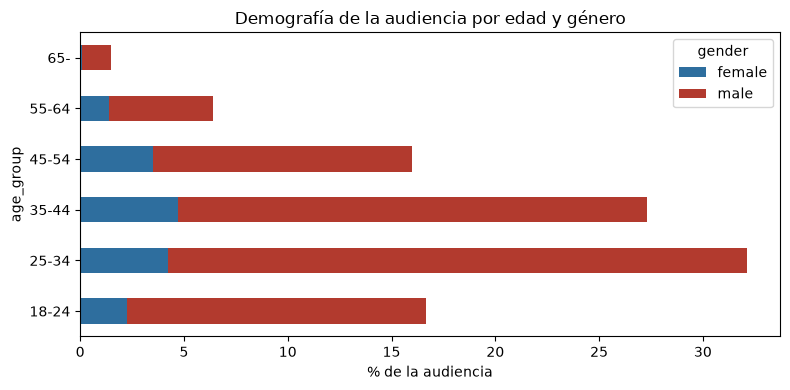

In [32]:
pivot_demo = demografia.pivot(index='age_group', columns='gender', values='viewer_percentage').fillna(0)
pivot_demo = pivot_demo.reindex(['18-24', '25-34', '35-44', '45-54', '55-64', '65-'])

plt.figure(figsize=(8, 4))
pivot_demo.plot(kind='barh', stacked=True, color=['#2E6E9E', '#B23A2E'], ax=plt.gca())
plt.xlabel('% de la audiencia')
plt.title('Demografía de la audiencia por edad y género')
plt.tight_layout()
plt.show()

### 3.7 Duración vs. retención media por vídeo

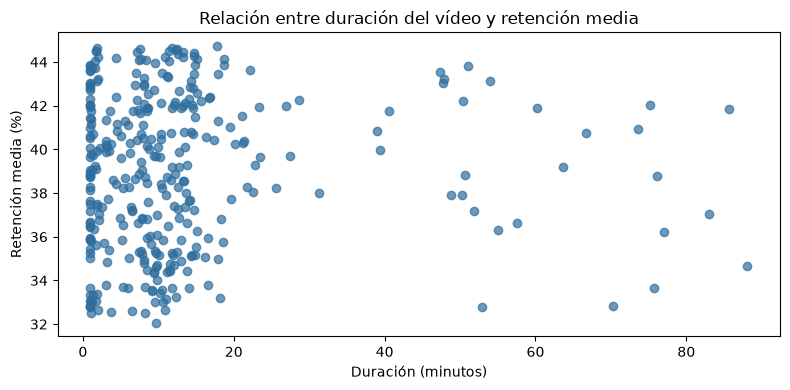

In [33]:
retencion_media_por_video = retencion.groupby('video_id')['audience_watch_ratio'].mean().rename('retencion_media')
video_con_retencion = video.merge(retencion_media_por_video, on='video_id', how='inner')

plt.figure(figsize=(8, 4))
plt.scatter(video_con_retencion['duracion_segundos'] / 60, video_con_retencion['retencion_media'] * 100,
            color='#2E6E9E', alpha=0.7)
plt.xlabel('Duración (minutos)')
plt.ylabel('Retención media (%)')
plt.title('Relación entre duración del vídeo y retención media')
plt.tight_layout()
plt.show()

### 3.8 Ingresos diarios vs. vistas diarias

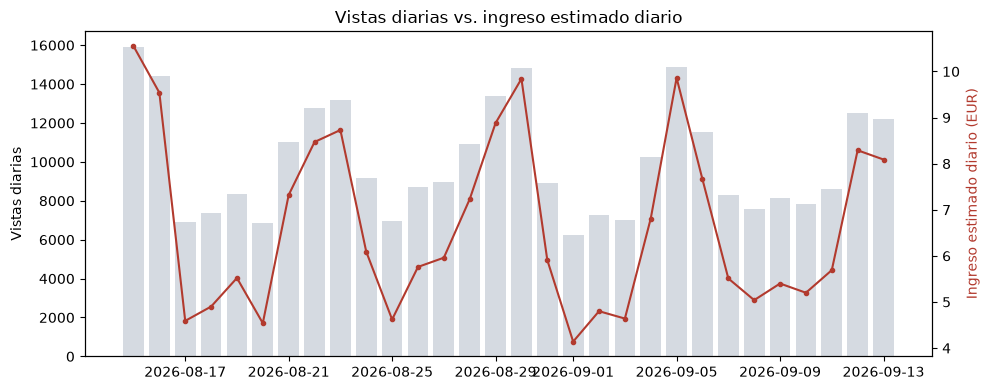

In [34]:
df_ing_ev = evolucion.merge(ingresos, on=['channel_id', 'fecha'])

fig, ax1 = plt.subplots(figsize=(10, 4))
ax1.bar(df_ing_ev['fecha'], df_ing_ev['views'], color='#D5DAE1', label='Vistas')
ax1.set_ylabel('Vistas diarias')

ax2 = ax1.twinx()
ax2.plot(df_ing_ev['fecha'], df_ing_ev['estimated_revenue'], color='#B23A2E', marker='o', markersize=3, label='Ingreso estimado (EUR)')
ax2.set_ylabel('Ingreso estimado diario (EUR)', color='#B23A2E')

plt.title('Vistas diarias vs. ingreso estimado diario')
fig.tight_layout()
plt.show()

## 4. Identificación de patrones

In [35]:
evolucion['dia_semana'] = evolucion['fecha'].dt.day_name()
orden_dias = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
patron_semanal = evolucion.groupby('dia_semana')[['views', 'suscriptores_netos']].mean().reindex(orden_dias)

print('Vistas y suscriptores netos medios por día de la semana:')
display(patron_semanal.round(1))

dia_top = patron_semanal['views'].idxmax()
print(f"\nEl día con más vistas medias es: {dia_top}")

Vistas y suscriptores netos medios por día de la semana:


,views,suscriptores_netos
dia_semana,,
Monday,8330.8,22.0
Tuesday,7049.0,18.8
Wednesday,8099.2,21.2
Thursday,7668.2,20.5
Friday,10201.5,27.2
Saturday,13890.2,35.8
Sunday,13230.8,33.8



El día con más vistas medias es: Saturday


In [36]:
# Engagement real (likes/vista) por categoría, no solo volumen de vistas
video['ratio_likes_vista'] = video['likes'] / video['views_totales']
video['ratio_comentarios_vista'] = video['comentarios'] / video['views_totales']

engagement_categoria = video.groupby('categoria')[['ratio_likes_vista', 'ratio_comentarios_vista']].mean()
engagement_categoria = engagement_categoria.sort_values('ratio_likes_vista', ascending=False)
print('Engagement medio (likes/vista y comentarios/vista) por categoría:')
display((engagement_categoria * 100).round(2).rename(columns=lambda c: c + ' (%)'))

Engagement medio (likes/vista y comentarios/vista) por categoría:


,ratio_likes_vista (%),ratio_comentarios_vista (%)
categoria,,
Curiosidades de fútbol,3.78,0.77
Fichajes,3.77,0.82
Seguimiento del club,3.74,0.82
Opinión post-partido,3.72,0.75
Afición,3.59,0.71


## 5. Identificación de anomalías

In [37]:
# Vídeos atípicos dentro de su propia categoría (z-score sobre views_totales)
video['z_views_categoria'] = video.groupby('categoria')['views_totales'].transform(
    lambda s: (s - s.mean()) / s.std()
)

picos_virales = video[video['z_views_categoria'] > 2][['titulo', 'categoria', 'views_totales', 'z_views_categoria']]
vídeos_bajo_rendimiento = video[video['z_views_categoria'] < -2][['titulo', 'categoria', 'views_totales', 'z_views_categoria']]

print(f'Vídeos con vistas anormalmente ALTAS para su categoría: {len(picos_virales)}')
display(picos_virales.sort_values('z_views_categoria', ascending=False).head(5))

print(f'\nVídeos con vistas anormalmente BAJAS para su categoría: {len(vídeos_bajo_rendimiento)}')
display(vídeos_bajo_rendimiento.sort_values('z_views_categoria').head(5))

Vídeos con vistas anormalmente ALTAS para su categoría: 20


,titulo,categoria,views_totales,z_views_categoria
258,Rumores de fichajes: novedad #259,Fichajes,17967,2.769193
111,Nuestra opinión tras el partido #112,Opinión post-partido,20016,2.758652
106,Así vive la afición el partido #107,Afición,16354,2.731541
0,Nuestra opinión tras el partido #1,Opinión post-partido,19844,2.727464
244,Rumores de fichajes: novedad #245,Fichajes,17030,2.568856



Vídeos con vistas anormalmente BAJAS para su categoría: 0


,titulo,categoria,views_totales,z_views_categoria


In [38]:
# Días anómalos en la evolución diaria (z-score sobre vistas)
evolucion['z_views_dia'] = (evolucion['views'] - evolucion['views'].mean()) / evolucion['views'].std()
dias_anomalos = evolucion[evolucion['z_views_dia'].abs() > 1.5][['fecha', 'views', 'suscriptores_netos', 'z_views_dia']]

print(f'Días con comportamiento anómalo respecto a la media del periodo: {len(dias_anomalos)}')
display(dias_anomalos.sort_values('z_views_dia'))

Días con comportamiento anómalo respecto a la media del periodo: 4


,fecha,views,suscriptores_netos,z_views_dia
1,2026-08-16,14394,38,1.520596
15,2026-08-30,14843,40,1.677165
21,2026-09-05,14869,37,1.686232
0,2026-08-15,15917,41,2.051677


## 6. Relaciones entre variables

In [39]:
correlaciones_video = video[['duracion_segundos', 'views_totales', 'likes', 'comentarios']].corr().round(2)
print('Matriz de correlación (nivel vídeo):')
display(correlaciones_video)

corr_duracion_retencion = video_con_retencion[['duracion_segundos', 'retencion_media']].corr().iloc[0, 1]
print(f"\nCorrelación duración vs. retención media: {corr_duracion_retencion:.3f}")

corr_views_ingreso = df_ing_ev[['views', 'estimated_revenue']].corr().iloc[0, 1]
print(f"Correlación vistas diarias vs. ingreso diario: {corr_views_ingreso:.3f}")

Matriz de correlación (nivel vídeo):


,duracion_segundos,views_totales,likes,comentarios
duracion_segundos,1.00,-0.03,-0.02,0.00
views_totales,-0.03,1.00,0.97,0.92
likes,-0.02,0.97,1.00,0.90
comentarios,0.00,0.92,0.90,1.00



Correlación duración vs. retención media: 0.035
Correlación vistas diarias vs. ingreso diario: 1.000


## 7. Segmentaciones interesantes

In [40]:
# Segmentación por franja de duración
def franja_duracion(segundos):
    minutos = segundos / 60
    if minutos < 5:
        return 'Corto (<5 min)'
    elif minutos <= 15:
        return 'Medio (5-15 min)'
    else:
        return 'Largo (>15 min)'

video['franja_duracion'] = video['duracion_segundos'].apply(franja_duracion)
video_con_retencion['franja_duracion'] = video_con_retencion['duracion_segundos'].apply(franja_duracion)

print('Vistas medias y retención media por franja de duración:')
resumen_franja = video.groupby('franja_duracion')['views_totales'].mean().to_frame('views_medias')
resumen_franja['retencion_media_%'] = (
    video_con_retencion.groupby('franja_duracion')['retencion_media'].mean() * 100
)
display(resumen_franja.round(1))

Vistas medias y retención media por franja de duración:


,views_medias,retencion_media_%
franja_duracion,,
Corto (<5 min),6371.5,38.8
Largo (>15 min),4674.5,39.6
Medio (5-15 min),5375.1,38.8


In [41]:
# Fin de semana (jornada de liga) vs. entre semana
evolucion['es_finde'] = evolucion['dia_semana'].isin(['Saturday', 'Sunday'])
comparativa_finde = evolucion.groupby('es_finde')[['views', 'suscriptores_netos']].mean()
comparativa_finde.index = comparativa_finde.index.map({True: 'Fin de semana', False: 'Entre semana'})
print('Vistas y suscriptores netos medios: fin de semana vs. entre semana')
display(comparativa_finde.round(1))

Vistas y suscriptores netos medios: fin de semana vs. entre semana


,views,suscriptores_netos
es_finde,,
Entre semana,8269.8,22.0
Fin de semana,13560.5,34.8


In [42]:
# Vídeos recientes (últimos 30 días de publicación) vs. histórico
fecha_corte = video['fecha_publicacion'].max() - pd.Timedelta(days=30)
video['es_reciente'] = video['fecha_publicacion'] > fecha_corte
comparativa_antiguedad = video.groupby('es_reciente')[['views_totales', 'likes']].mean()
comparativa_antiguedad.index = comparativa_antiguedad.index.map({True: 'Últimos 30 días', False: 'Resto del histórico'})
print('Vistas y likes medios: vídeos recientes vs. histórico')
display(comparativa_antiguedad.round(1))

Vistas y likes medios: vídeos recientes vs. histórico


,views_totales,likes
es_reciente,,
Resto del histórico,5535.3,207.2
Últimos 30 días,6183.3,246.3


## 8. Conclusiones principales

El siguiente resumen se genera **a partir de los números reales de esta ejecución**, no es texto fijo — cámbialo si tu ejecución da valores distintos a los de otra persona del grupo (los datos reales de PuroBalompie que cada uno use como base cambian ligeramente el resultado).

In [43]:
categoria_top = resumen_categoria.idxmax()
fuente_top = trafico_ordenado.iloc[0]
pct_fuente_top = fuente_top['views'] / trafico_ordenado['views'].sum() * 100
caida_inicial_pct = (1 - curva_retencion.iloc[1]) * 100  # caída en el primer punto tras el 0%

print('RESUMEN EJECUTIVO')
print('=' * 60)
print(f"- El día con más audiencia media es {dia_top}, coherente con la agenda de partidos.")
print(f"- La categoría con más vistas medias por vídeo es '{categoria_top}'.")
print(f"- La fuente de tráfico dominante es '{fuente_top['traffic_source_type']}' con el {pct_fuente_top:.1f}% de las vistas.")
print(f"- La retención cae un {caida_inicial_pct:.0f}% ya en el primer tramo del vídeo (primer 5%).")
print(f"- El RPM medio real del periodo es de {rpm_medio:.2f} EUR por cada 1.000 vistas.")
print(f"- Correlación duración-retención: {corr_duracion_retencion:.2f} "
      f"({'los vídeos más largos retienen peor' if corr_duracion_retencion < -0.2 else 'sin relación clara' if abs(corr_duracion_retencion) <= 0.2 else 'los vídeos más largos retienen mejor'}).")

RESUMEN EJECUTIVO
- El día con más audiencia media es Saturday, coherente con la agenda de partidos.
- La categoría con más vistas medias por vídeo es 'Curiosidades de fútbol'.
- La fuente de tráfico dominante es 'SUGGESTED_VIDEO' con el 38.5% de las vistas.
- La retención cae un 45% ya en el primer tramo del vídeo (primer 5%).
- El RPM medio real del periodo es de 0.66 EUR por cada 1.000 vistas.
- Correlación duración-retención: 0.03 (sin relación clara).


## 9. Detección de problemas / oportunidades (mínimo 3)

Se marcan automáticamente a partir de umbrales sobre los datos reales de esta ejecución, para evitar dar por sentado un problema que los datos no respalden.

In [44]:
problemas_detectados = []

if pct_fuente_top > 35:
    problemas_detectados.append(
        f"Dependencia excesiva de una sola fuente de tráfico ('{fuente_top['traffic_source_type']}', "
        f"{pct_fuente_top:.1f}% de las vistas): riesgo alto si el algoritmo de recomendación cambia."
    )

if caida_inicial_pct > 30:
    problemas_detectados.append(
        f"Retención temprana baja: se pierde un {caida_inicial_pct:.0f}% de la audiencia en el primer "
        f"5% del vídeo, lo que reduce impresiones publicitarias mid-roll y reproducciones completas."
    )

if rpm_medio < 2.0:
    problemas_detectados.append(
        f"Monetización efectiva baja: RPM medio de {rpm_medio:.2f} EUR/1000 vistas, muy por debajo de lo "
        f"que necesitaría el canal para ser rentable con su volumen actual de audiencia."
    )

if dia_top in ('Saturday', 'Sunday') :
    problemas_detectados.append(
        f"Posible desalineación entre publicación y consumo: el pico real de audiencia es en {dia_top}, "
        f"conviene confirmar que el calendario de publicación aprovecha esa ventana."
    )

print(f'Problemas/oportunidades detectados: {len(problemas_detectados)}\n')
for i, p in enumerate(problemas_detectados, 1):
    print(f'{i}. {p}\n')

Problemas/oportunidades detectados: 4

1. Dependencia excesiva de una sola fuente de tráfico ('SUGGESTED_VIDEO', 38.5% de las vistas): riesgo alto si el algoritmo de recomendación cambia.

2. Retención temprana baja: se pierde un 45% de la audiencia en el primer 5% del vídeo, lo que reduce impresiones publicitarias mid-roll y reproducciones completas.

3. Monetización efectiva baja: RPM medio de 0.66 EUR/1000 vistas, muy por debajo de lo que necesitaría el canal para ser rentable con su volumen actual de audiencia.

4. Posible desalineación entre publicación y consumo: el pico real de audiencia es en Saturday, conviene confirmar que el calendario de publicación aprovecha esa ventana.



## 10. Problema seleccionado y traducción a Ciencia de Datos

*(Completar tras revisar la lista impresa arriba con los datos reales de vuestra ejecución. Se deja aquí un ejemplo de cómo redactarlo, tomando como hipótesis de trabajo la retención temprana — sustituidlo si vuestros datos apuntan a otro problema de la lista.)*

**Problema seleccionado:** retención temprana baja.

**Por qué este y no otro:** es el problema con más palanca de mejora directa por parte del cliente (depende del propio contenido, no de factores externos como el algoritmo de YouTube), y afecta en cascada a dos síntomas ya detectados: menos impresiones publicitarias por vídeo y menor conversión a suscriptor, ya que YouTube prioriza en 'sugeridos' los vídeos que retienen bien.

**Traducción a Ciencia de Datos:**
- **Tipo de problema:** análisis explicativo / correlacional, no requiere un modelo predictivo complejo a esta escala de datos.
- **Variables de entrada:** `categoria`, `duracion_segundos`, `franja_duracion`, `fecha_publicacion` (día de la semana) de cada vídeo.
- **Variable objetivo:** caída de retención en el primer 15% del vídeo (`audience_watch_ratio` en `elapsed_video_time_ratio` bajo).
- **Método:** comparación de medias por segmento (ya hecho en la sección 7) + correlación (sección 6); si se quisiera ir más allá, una regresión lineal múltiple con estas variables explicativas sobre la caída de retención.
- **Output accionable para GrowUP:** una recomendación editorial concreta, del tipo *"los vídeos de categoría X y más de Y minutos pierden Z puntos porcentuales más de audiencia en el arranque que la media del canal — recomendamos abrir con el momento más atractivo del contenido en los primeros 15 segundos, o acortar la introducción"*.
- **Cómo se mediría el éxito:** comparar la curva de retención media de los vídeos publicados tras aplicar el cambio frente a la curva histórica calculada en la sección 3.4.